# Gemini Visual Text Query Probe

This notebook tests two ad hoc text queries against saved Gemini product embeddings:

- `I want to buy a whisky with round bottle`
- `I want to buy a whisky in green bottle.`

For each query, it shows the top 5 products from two product-side vector spaces:

- product image embeddings
- product image + text multimodal embeddings

The notebook calls Gemini only for missing cached query embeddings. Product embeddings are loaded from disk.

In [6]:
from __future__ import annotations

import base64
import json
import re
import sys
from pathlib import Path

import numpy as np
from IPython.display import HTML, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from rs_demo.embeddings import NumpyEmbeddingStore  # noqa: E402
from rs_demo.gemini_embeddings import GeminiEmbeddingModel  # noqa: E402
from rs_demo.retrieval import cosine_scores  # noqa: E402

PRODUCT_PATH = ROOT / "data/extracted/product_parse_sample.jsonl"
PRODUCT_EMBEDDING_DIR = ROOT / "data/embeddings/gemini"
QUERY_CACHE_DIR = ROOT / "data/embeddings/gemini/ad_hoc_queries/visual_text"

QUERY_CACHE_DIR.mkdir(parents=True, exist_ok=True)

ROOT

PosixPath('/Users/eltonli/code/rs-demo')

In [7]:
def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]


products = {record["product_id"]: record for record in load_jsonl(PRODUCT_PATH)}
product_batch = NumpyEmbeddingStore(PRODUCT_EMBEDDING_DIR).read()
product_ids_by_row = product_batch.product_ids

print("products:", len(products))
print("product image embeddings:", product_batch.image_embeddings.shape)
print("product multimodal embeddings:", product_batch.multimodal_embeddings.shape)

products: 533
product image embeddings: (533, 768)
product multimodal embeddings: (533, 768)


## Embed the Two Query Texts

The query text is embedded once and cached under `data/embeddings/gemini/ad_hoc_queries/visual_text/`.

In [8]:
queries = {
    "round_bottle": "I want to buy a whisky with round bottle",
    "green_bottle": "I want to buy a whisky in green bottle.",
}

# Set True if you want to spend API calls and refresh these two query embeddings.
force_embed = False


def safe_name(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_-]+", "_", value).strip("_").lower()


def embed_query_text(query_id: str, query: str) -> np.ndarray:
    cache_path = QUERY_CACHE_DIR / f"{safe_name(query_id)}.npy"
    if cache_path.exists() and not force_embed:
        return np.load(cache_path)

    model = GeminiEmbeddingModel(dimension=768)
    vector = model.embed_text(f"task: search result | query: {query}")
    np.save(cache_path, vector)
    return vector


query_embeddings = {
    query_id: embed_query_text(query_id, query)
    for query_id, query in queries.items()
}

{query_id: vector.shape for query_id, vector in query_embeddings.items()}

{'round_bottle': (768,), 'green_bottle': (768,)}

In [9]:
def html_escape(value: object) -> str:
    return (
        str(value or "")
        .replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
        .replace('"', "&quot;")
    )


def image_tag(path: str | None, width: int = 90) -> str:
    if not path:
        return ""
    image_path = ROOT / path
    if not image_path.exists():
        return f"<small>missing image: {html_escape(path)}</small>"
    suffix = image_path.suffix.lower().lstrip(".")
    mime = "jpeg" if suffix in {"jpg", "jpeg"} else suffix
    encoded = base64.b64encode(image_path.read_bytes()).decode("ascii")
    return f'<img src="data:image/{mime};base64,{encoded}" width="{width}">'


def product_summary(product_id: str) -> dict:
    record = products[product_id]
    return {
        "product_id": product_id,
        "name": record.get("name"),
        "brand": record.get("brand_or_distillery"),
        "style": record.get("style"),
        "region": record.get("region"),
        "country": record.get("country"),
        "abv": record.get("abv"),
        "description": record.get("description"),
        "image_path": record.get("cropped_product_image_path") or record.get("product_image_path"),
    }


def rank_products(query_vector: np.ndarray, product_vectors: np.ndarray, top_k: int = 5) -> list[tuple[int, str, float]]:
    scores = cosine_scores(query_vector, product_vectors)
    order = np.argsort(-scores, kind="stable")[:top_k]
    return [(rank, product_ids_by_row[index], float(scores[index])) for rank, index in enumerate(order, start=1)]


def render_results(title: str, rows: list[tuple[int, str, float]]) -> str:
    body = []
    for rank, product_id, score in rows:
        product = product_summary(product_id)
        body.append(
            f"""
            <tr>
              <td>{rank}</td>
              <td>{score:.4f}</td>
              <td>{image_tag(product['image_path'], width=78)}</td>
              <td><code>{html_escape(product_id)}</code><br>
              <b>{html_escape(product['name'])}</b><br>
              {html_escape(product['brand'])} · {html_escape(product['style'])} ·
              {html_escape(product['region'])} · {html_escape(product['country'])} ·
              {html_escape(product['abv'])}% ABV<br>
              <small>{html_escape(product['description'])}</small></td>
            </tr>
            """
        )
    return f"""
    <h3>{html_escape(title)}</h3>
    <table>
      <tr><th>Rank</th><th>Score</th><th>Image</th><th>Product</th></tr>
      {''.join(body)}
    </table>
    """


def show_query_results(query_id: str, top_k: int = 5) -> None:
    query = queries[query_id]
    query_vector = query_embeddings[query_id]
    image_rows = rank_products(query_vector, product_batch.image_embeddings, top_k=top_k)
    multimodal_rows = rank_products(query_vector, product_batch.multimodal_embeddings, top_k=top_k)

    display(HTML(f"<h2>{html_escape(query_id)}</h2><p><b>Query:</b> {html_escape(query)}</p>"))
    display(HTML(render_results("Top 5 from product image embeddings", image_rows)))
    display(HTML(render_results("Top 5 from product image + text embeddings", multimodal_rows)))

## Results

Rank,Score,Image,Product
1,0.6646,,"p0108-dimple-12-year-old DIMPLE 12-YEAR-OLD DIMPLE / PINCH · Blend · · Scotland · 40.0% ABV Aromas of fudge, with woody notes. Hints of mint, and an initial richness on the palate, with candy apples and caramel; spiciness and dried fruits too."
2,0.6646,,"p0108-dimple-15-year-old DIMPLE 15-YEAR-OLD DIMPLE / PINCH · Blend · · Scotland · 43.0% ABV In this blend, there are hints of smoke, chocolate, and cocoa, completed by a long, rich finish."
3,0.6609,,"p0161-the-glenrothes-select-reserve THE GLENROTHES SELECT RESERVE THE GLENROTHES SELECT · Single Malt · Speyside · · 43.0% ABV Like non-vintage Champagne, this is a vatting of different ages to produce a complex whisky with notes of hard candy, ripe fruit, vanilla, and spice. Sweeter on the nose than in the mouth."
4,0.6609,,"p0161-the-glenrothes-1975 THE GLENROTHES 1975 THE GLENROTHES SELECT · Single Malt · Speyside · · 43.0% ABV Increasingly hard to find, this vintage offers big, rich flavors—stewed fruits, toffee, bitter chocolate, and orange peel. Medium-sweet satisfying finish. malt, a 12-year-old was released. At first, Glenrothes failed to stand out: it had entered the 12-year-old stakes late in the day and there was plenty of competition, particularly on Speyside. This all changed with the launch of the highly acclaimed Glenrothes Vintage malt in 1994. The brand owners, wine merchants Berry Brothers & Rudd, realized vintage variation might be appreciated by malt-whisky-lovers as well as wine-lovers. In 2004, Glenrothes Select Reserve was released to provide continuity between vintages."
5,0.6538,,"p0173-guillon-no-1 GUILLON NO. 1 GUILLON · Single Malt · · France · 46.0% ABV Highly aromatic, fruity, and elegant, thanks to the unusual finish in sweet-wine casks."

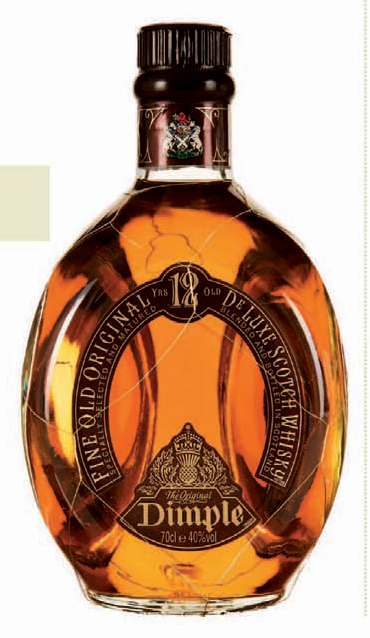
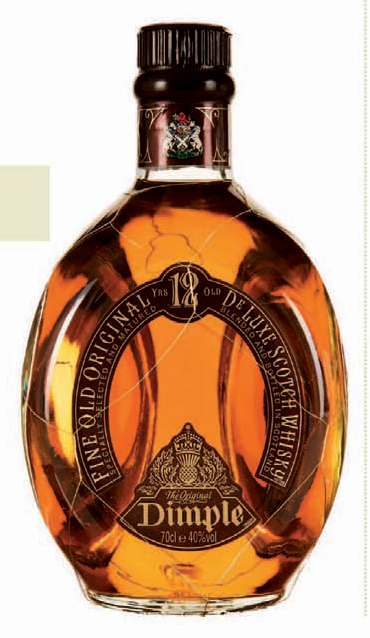
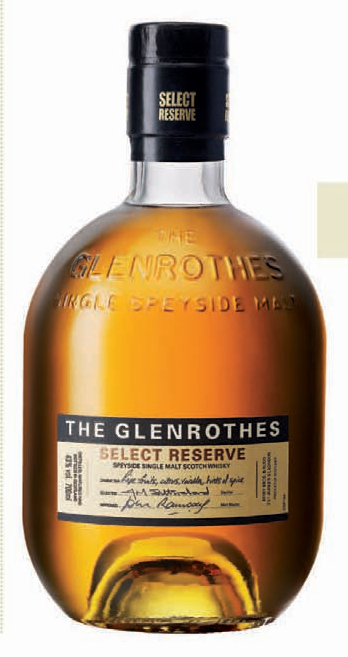
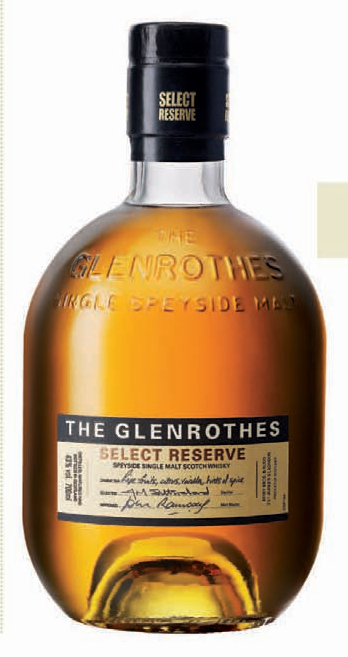
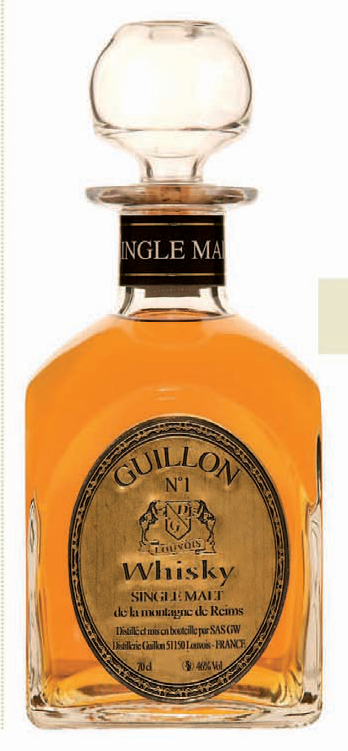

Rank,Score,Image,Product
1,0.7030,,"p0161-the-glenrothes-select-reserve THE GLENROTHES SELECT RESERVE THE GLENROTHES SELECT · Single Malt · Speyside · · 43.0% ABV Like non-vintage Champagne, this is a vatting of different ages to produce a complex whisky with notes of hard candy, ripe fruit, vanilla, and spice. Sweeter on the nose than in the mouth."
2,0.6861,,"p0161-the-glenrothes-1975 THE GLENROTHES 1975 THE GLENROTHES SELECT · Single Malt · Speyside · · 43.0% ABV Increasingly hard to find, this vintage offers big, rich flavors—stewed fruits, toffee, bitter chocolate, and orange peel. Medium-sweet satisfying finish. malt, a 12-year-old was released. At first, Glenrothes failed to stand out: it had entered the 12-year-old stakes late in the day and there was plenty of competition, particularly on Speyside. This all changed with the launch of the highly acclaimed Glenrothes Vintage malt in 1994. The brand owners, wine merchants Berry Brothers & Rudd, realized vintage variation might be appreciated by malt-whisky-lovers as well as wine-lovers. In 2004, Glenrothes Select Reserve was released to provide continuity between vintages."
3,0.6788,,"p0108-dimple-12-year-old DIMPLE 12-YEAR-OLD DIMPLE / PINCH · Blend · · Scotland · 40.0% ABV Aromas of fudge, with woody notes. Hints of mint, and an initial richness on the palate, with candy apples and caramel; spiciness and dried fruits too."
4,0.6760,,"p0173-guillon-no-1 GUILLON NO. 1 GUILLON · Single Malt · · France · 46.0% ABV Highly aromatic, fruity, and elegant, thanks to the unusual finish in sweet-wine casks."
5,0.6758,,"p0034-balblair-75 BALBLAIR 75 BALBLAIR · Single Malt · Highlands · Scotland · 46.0% ABV The sherry-matured vintage expression has a distinct rum-raisin character, with notes of butterscotch and some underlying fruit flavors that taper to a long finish."

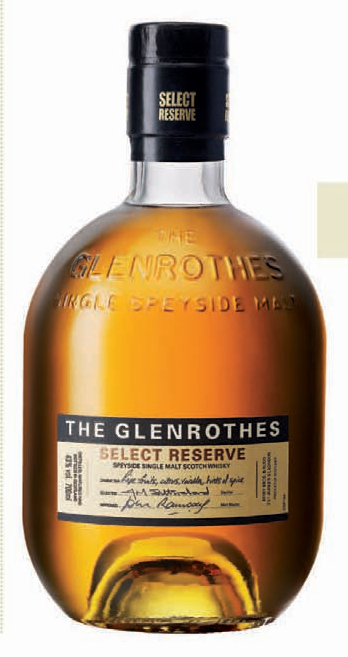
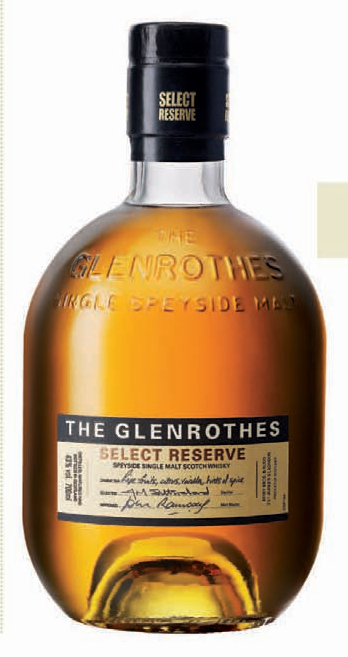
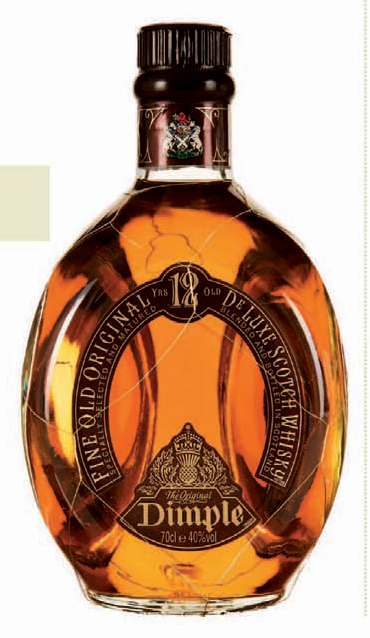
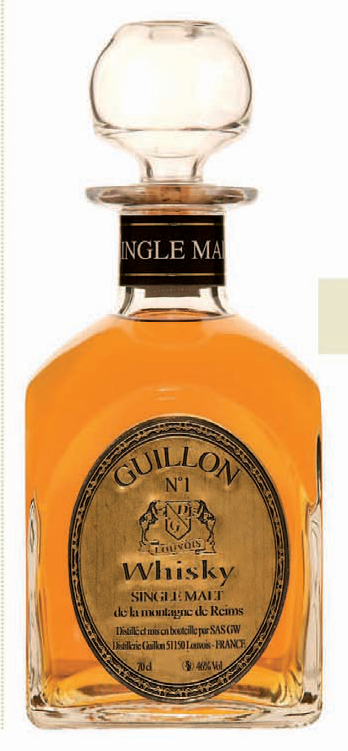
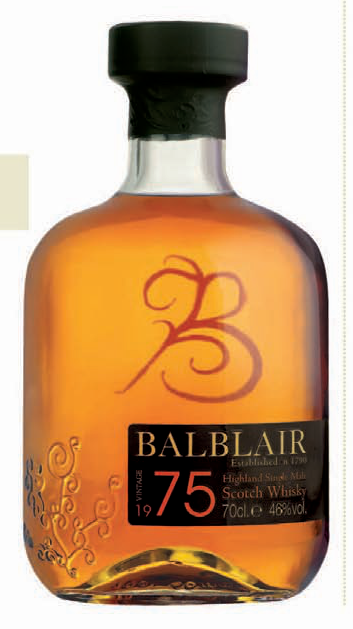

Rank,Score,Image,Product
1,0.6688,,"p0155-the-glenlivet-12-year-old THE GLENLIVET 12-YEAR-OLD GLENLIVET · Single Malt · Speyside · Scotland · 40.0% ABV Citrusy and heathery, with a scent of fresh wood and soft fruit, a light to medium body, and a dry, clean finish."
2,0.6688,,"p0155-the-glenlivet-french-oak-reserve-15-year-old THE GLENLIVET FRENCH OAK RESERVE 15-YEAR-OLD GLENLIVET · Single Malt · Speyside · Scotland · 40.0% ABV A smoother, richer take on the 12-year-old, with a malty, strawberriesand-cream flavor laced with spice."
3,0.6677,,"p0148-glenfiddich-12-year-old GLENFIDDICH 12-YEAR-OLD GLENFIDDICH · Single Malt · Speyside · Scotland · 40.0% ABV A gentle aperitif-style whisky with a malty, grassy flavor and a little vanilla sweetness. Quite soft."
4,0.6677,,"p0148-glenfiddich-15-year-old-solera-reserve GLENFIDDICH 15-YEAR-OLD SOLERA RESERVE GLENFIDDICH · Single Malt · Speyside · Scotland · 40.0% ABV After 15 years in American oak, this is finished off in Spanish casks for an extra-soft layer of fresh fruit and spice."
5,0.6673,,"p0318-signature SIGNATURE SIGNATURE · Blend · · India · 42.8% ABV A rich nose, with a distinct medicinal note. Straight, the taste is surprisingly sweet, with smoky and medicinal undertones, becoming less sweet with water. Relatively light in body, with a distinct peaty, smoky edge."

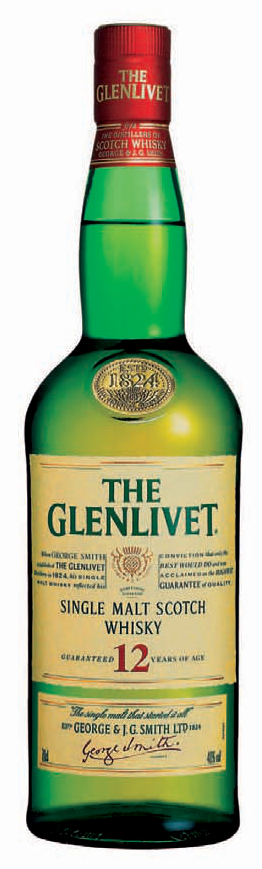
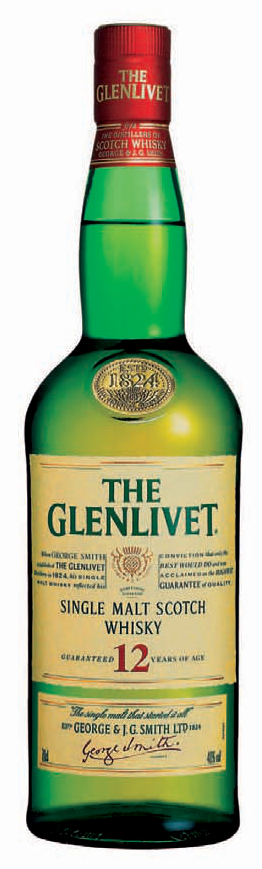
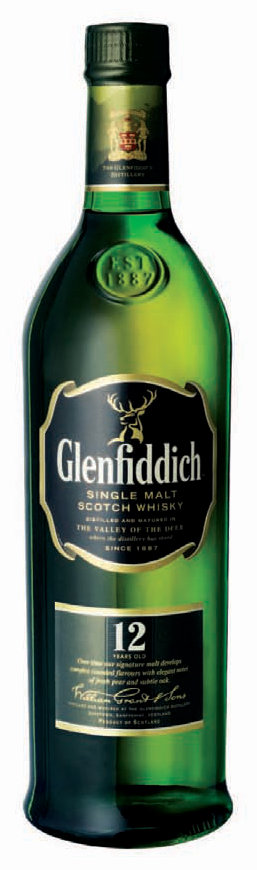
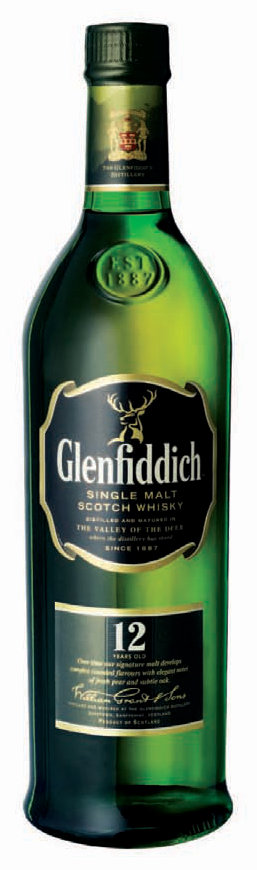
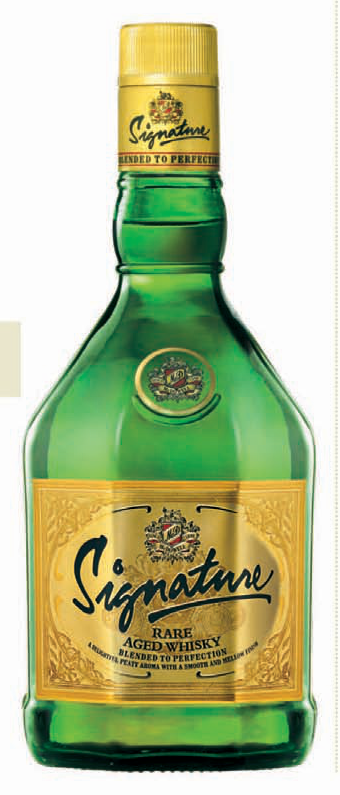

Rank,Score,Image,Product
1,0.7101,,"p0208-johnnie-walker-green-label JOHNNIE WALKER GREEN LABEL JOHNNIE WALKER · Blended Malt · · Scotland · 43.0% ABV Complex, rich, and powerful. Pepper and oak, fruit aromas, a malty sweetness, and some smoke."
2,0.6899,,"p0170-green-spot GREEN SPOT GREEN SPOT · Pure Pot Still · · Ireland · 40.0% ABV Green Spot is matured for just six to eight years, but a glass of this is still bracing stuff, with a wonderful, lightly sherried finish. One of a kind."
3,0.6869,,"p0148-glenfiddich-12-year-old GLENFIDDICH 12-YEAR-OLD GLENFIDDICH · Single Malt · Speyside · Scotland · 40.0% ABV A gentle aperitif-style whisky with a malty, grassy flavor and a little vanilla sweetness. Quite soft."
4,0.6830,,"p0148-glenfiddich-15-year-old-solera-reserve GLENFIDDICH 15-YEAR-OLD SOLERA RESERVE GLENFIDDICH · Single Malt · Speyside · Scotland · 40.0% ABV After 15 years in American oak, this is finished off in Spanish casks for an extra-soft layer of fresh fruit and spice."
5,0.6829,,"p0152-glengoyne-10-year-old GLENGOYNE 10-YEAR-OLD GLENGOYNE · Single Malt · Highlands · Scotland · 40.0% ABV This unpeated whisky has a clean, grassy aroma, with a nutty sweetness that comes through on the palate."

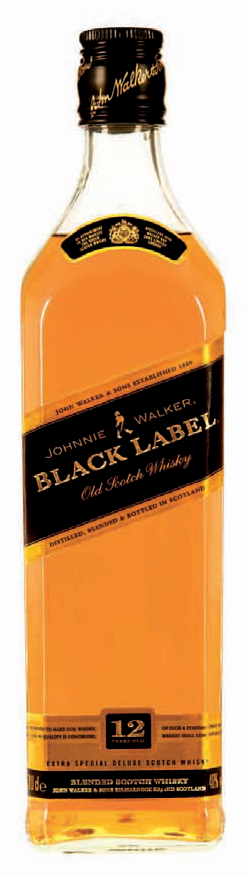
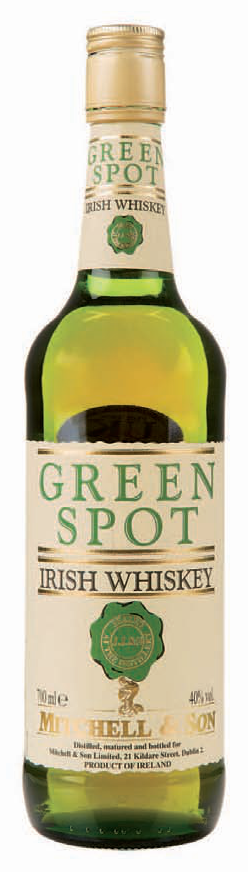
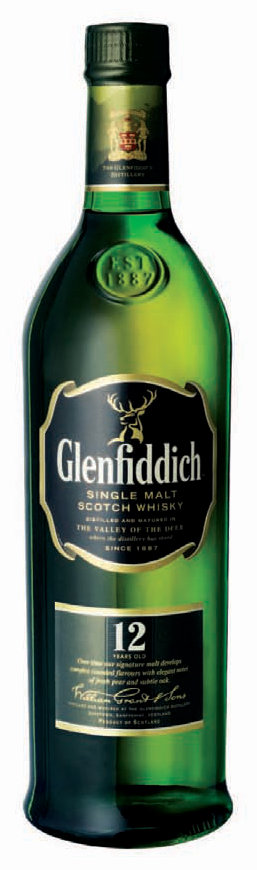
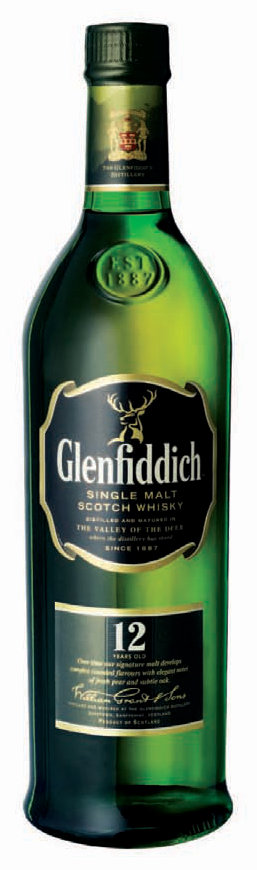
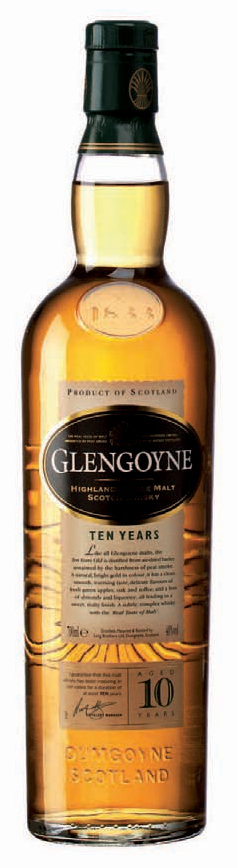

In [10]:
for query_id in queries:
    show_query_results(query_id, top_k=5)